RNN의 문제점
- 연산량이 크다

- 기울기 소실(정보소실)

- LSTM 하나만 사용하면 각 나라의 어순을 알 수가 없다. --> 번역에 사용하기가 힘들다. 

# seq2seq

## Encoder

In [ ]:
import tensorflow as tf

In [ ]:
class Encoder(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, enc_units):
    super(Encoder, self).__init__()
    self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
    self.lstm = tf.keras.layers.LSTM(enc_units) # return_sequence라는 파라미터가 안에 있는게 default = False

  def call(self, x):
    print('입력 shape:', x.shape)

    x = self.embedding(x)
    print('Embedding Layer를 거친 shape :', x.shape)

    output = self.lstm(x)
    print('LSTM shape의 ouptut shape :', output.shape)

    return output

In [ ]:
# 임의로 하나 해보자
vocab_size = 30000
emb_size = 256
lstm_size = 512
batch_size = 1
sample_seq_len = 3

print('Vocab Size : {0}'.format(vocab_size))
print('Embedding Size : {0}'.format(emb_size))
print('LSTM Size : {0}'.format(lstm_size))
print('Batch Size : {0}'.format(batch_size))
print('Sample Sequence Length : {0}'.format(sample_seq_len))


Vocab Size : 30000
Embedding Size : 256
LSTM Size : 512
Batch Size : 1
Sample Sequence Length : 3


In [ ]:
encoder = Encoder(vocab_size, emb_size, lstm_size)
sample_input = tf.zeros((batch_size, sample_seq_len)) # 1, 3

sample_output = encoder(sample_input)

입력 shape: (1, 3)
Embedding Layer를 거친 shape : (1, 3, 256)
LSTM shape의 ouptut shape : (1, 512)


![](https://aiffelstaticprd.blob.core.windows.net/media/images/GN-4-L-6.max-800x600.jpg)

## LSTM Decoder

In [ ]:
class Decoder(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, dec_units):
    super(Decoder, self).__init__()
    self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
    self.lstm = tf.keras.layers.LSTM(dec_units, return_sequences=True)
    self.fc = tf.keras.layers.Dense(vocab_size)
    self.softmax = tf.keras.layers.Softmax(axis=-1)

  def call(self, x, context_v):
    print('입력shape :', x.shape)

    x = self.embedding(x)
    print('Embedding Layer를 거친 Shape :', x.shape)

    context_v = tf.repeat(tf.expand_dims(context_v, axis=1), repeats=x.shape[1], axis=1)
    x = tf.concat([x, context_v], axis=-1)
    print('Context Vector가 더해진 shape :', x.shape)

    x = self.lstm(x)
    print('LSTM Layer의 Output shape :', x.shape)

    output = self.fc(x)
    print('Decoder의 최종 Output shape :', output.shape)

    return self.softmax(output)

In [ ]:
print('Vocab Size : {0}'.format(vocab_size))
print('Embedding Size : {0}'.format(emb_size))
print('LSTM Size : {0}'.format(lstm_size))
print('Batch Size : {0}'.format(batch_size))
print('Sample Sequence Length : {0}'.format(sample_seq_len))

Vocab Size : 30000
Embedding Size : 256
LSTM Size : 512
Batch Size : 1
Sample Sequence Length : 3


In [ ]:
# 만든 임의의 사이즈를 decoder에 집어넣어보자
decoder =Decoder(vocab_size, emb_size, lstm_size)
sample_input = tf.zeros((batch_size, sample_seq_len))

dec_output = decoder(sample_input, sample_output)

입력shape : (1, 3)
Embedding Layer를 거친 Shape : (1, 3, 256)
Context Vector가 더해진 shape : (1, 3, 768)
LSTM Layer의 Output shape : (1, 3, 512)
Decoder의 최종 Output shape : (1, 3, 30000)


![](https://aiffelstaticprd.blob.core.windows.net/media/images/GN-4-L-7.max-800x600.jpg)

# 어텐션 메커니즘(Attention )

- 어텐션 아이디어는 디코더에서 출력 단어를 예측하는 매 시점(time step)마다 인코더에서 전체 입력문장을 다시한번 참고한다는 점
- 전체 입력 문장을 전부 다 동일한 비율로 참고하는 것이 아니라, 해당 시점에서 예측해야할 단어와 연관이 있는 입력 단어 부분을 좀 더 집중해서 보자

In [ ]:
dict = {'2017' : 'Transformer', '2018' : 'Bert'}

In [ ]:
print(dict['2017'])

Transformer


![](https://wikidocs.net/images/page/22893/%EC%BF%BC%EB%A6%AC.PNG)

Attention(Q, K, V) = Attention Value

```
Q = Query : t시점의 디코더 셀에서의 은닉 상태
K = Keys : 모든 시점의 인코더 셀의 은닉 상태들
V = Values : 모든 시점의 인코더 셀의 은닉 상태들
```

## Dot-Product Attention

![](https://wikidocs.net/images/page/22893/dotproductattention1_final.PNG)

### 어텐션 스코어 구하기

![](https://wikidocs.net/images/page/22893/dotproductattention2_final.PNG)

$$score(s_t, h_i) = S_t^T h_i $$

$$e^t = [s_t^T h_1, ..., s_t^T h_N]$$

### 소프트함수를 적용해서 구하게된다

![](https://wikidocs.net/images/page/22893/dotproductattention3_final.PNG)

$${\alpha}^t = softmax(e^t)$$

### 각 인코더의 어텐션 가중치와 은닉상태를 가중합하여 어텐션 값(Attention Value를 구한다.

![](https://wikidocs.net/images/page/22893/dotproductattention4_final.PNG)

$$a_t = \sum_{i=1}^{N}{a_i^th_i}$$ 

### 어텐션 값과 디코더의 t시점의 은닉 상태를 연결한다.

![](https://wikidocs.net/images/page/22893/dotproductattention5_final_final.PNG)

### 출력층 연산의 입력이 되는 $\tilde{s_t}$를 계산한다.

![](https://wikidocs.net/images/page/22893/st.PNG)

$$ \tilde{s_{t}}=tanh(W_c[a_t ; s_t] + b_c)$$

$$ \hat{y_t}=Softmax(W_y\tilde{s_t}+b_y)$$

### $\tilde{s_t}$를 출력층의 입력으로 사용한다.

## Bahdanau Attention

- Bahdanau Attention
$$ Score_{alignment} = W * tanh(W_{decoder} * H_{decoder} + W_{encoder} * H_{encoder}) $$

In [25]:
# 식을 구현해보자
class BahdanauAttention(tf.keras.layers.Layer):
  def __init__(self, units):
    super(BahdanauAttention, self).__init__()
    self.W_decoder = tf.keras.layers.Dense(units)
    self.W_encoder = tf.keras.layers.Dense(units)
    self.W_combine = tf.keras.layers.Dense(1)
  
  def call(self, H_encoder, H_decoder):
    print("[H_encoder] shape :", H_encoder.shape)

    H_encoder = self.W_encoder(H_encoder)
    print("[W_encoder X H_encoder shape:", H_encoder.shape)

    print("\n[H_decoder] shape: ", H_decoder.shape)
    H_decoder = tf.expand_dims(H_decoder, 1)
    H_decoder = self.W_decoder(H_decoder)

    print("[W_decoder X H_decoder] shape:", H_decoder.shape)

    score = self.W_combine(tf.nn.tanh(H_decoder+H_encoder))
    print("Score Alignment] shape :", score.shape)

    attention_weights = tf.nn.softmax(score, axis = 1)
    print("\n 최종 weight : \n", attention_weights.numpy())

    context_vector = attention_weights * H_decoder
    context_vector = tf.reduce_sum(context_vector, axis=1)

    return context_vector, attention_weights
  
  W_size = 100

  print("Hidden State를 {0}차원으로 Mapping \n".format(W_size))

  attention = BahdanauAttention(W_size)

  enc_state = tf.random.uniform((1,10, 512))
  dec_state = tf.random.uniform((1, 512))

  _ = attention(enc_state, dec_state)

Hidden State를 100차원으로 Mapping 

[H_encoder] shape : (1, 10, 512)
[W_encoder X H_encoder shape: (1, 10, 100)

[H_decoder] shape:  (1, 512)
[W_decoder X H_decoder] shape: (1, 1, 100)
Score Alignment] shape : (1, 10, 1)

 최종 weight : 
 [[[0.03698577]
  [0.13235506]
  [0.14210957]
  [0.10677454]
  [0.08009412]
  [0.1029195 ]
  [0.04503505]
  [0.1325519 ]
  [0.09499109]
  [0.12618336]]]


In [ ]:
# 웨이트 스코어값을 시각화 시켜서 보자

![](https://aiffelstaticprd.blob.core.windows.net/media/original_images/GN-4-L-9.jpg)

## Loung Attention

$$ Score(H_{target}, H_{encoder}) = H_{target}^T*W_{combine}*H_{encoder}$$

In [40]:
# 식으로 구현해보자
class LuongAttention(tf.keras.layers.Layer):
  def __init__(self, units):
    super(LuongAttention, self).__init__()
    self.W_combine = tf.keras.layers.Dense(units)

  def call(self, H_encoder, H_decoder):
    print('[H_encoder] shape :', H_encoder.shape)

    WH = self.W_combine(H_encoder)
    print('[W_encoder X H_encoder] shape :', WH.shape)

    H_decoder = tf.expand_dims(H_decoder, 1)
    alignment = tf.matmul(WH, tf.transpose(H_decoder, [0, 2, 1]))
    print('[Score_alignment] shape :', alignment.shape)

    attention_weights = tf.nn.softmax(alignment, axis = 1)
    print('\n 최종 weight : \n', attention_weights.numpy())

    attention_weights = tf.squeeze(attention_weights, axis=-1)
    context_vector = tf.matmul(attention_weights, H_encoder)

    return context_vector, attention_weights

In [41]:
emb_size = 512
attention = LuongAttention(emb_size)

enc_state = tf.random.uniform((1, 10, emb_size))
dec_state = tf.random.uniform((1, emb_size))

_ = attention(enc_state, dec_state)

[H_encoder] shape : (1, 10, 512)
[W_encoder X H_encoder] shape : (1, 10, 512)
[Score_alignment] shape : (1, 10, 1)

 최종 weight : 
 [[[1.02002895e-03]
  [2.81515658e-01]
  [1.20925754e-01]
  [2.13474020e-01]
  [1.69216038e-03]
  [4.77937756e-05]
  [2.92268978e-03]
  [3.71561987e-06]
  [3.77634525e-01]
  [7.63668097e-04]]]


# 양방향 LSTM과 어텐션 메커니즘(IMDB 리뷰 데이터)

## IMDB리뷰데이터 전처리하기

In [3]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [4]:
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words = vocab_size)

17465344/17464789 [==============================] - 0s 0us/step


<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/datasets/imdb.py:155: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  x_train, y_train = np.array(xs[:idx]), np.array(labels[:idx])
/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/datasets/imdb.py:156: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 

In [5]:
print('리뷰의 최대 길이 : {}'.format(max(len(I)for I in x_train)))
print('리뷰의 평균 길이 : {}'.format(sum(map(len, x_train))/len(x_train)))


리뷰의 최대 길이 : 2494
리뷰의 평균 길이 : 238.71364


In [6]:
max_len = 500
x_train = pad_sequences(x_train, maxlen = max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

### 바다나우 어텐션 정의

$$score(query, key)=V^T tanh(W_1 key + W_2 query) $$

In [7]:
# v = weight 

In [8]:
import tensorflow as tf

In [9]:
class BahdanauAttention(tf.keras.Model):
  def __init__(self, units):
    super(BahdanauAttention, self).__init__()
    self.W1 = Dense(units)
    self.W2 = Dense(units)
    self.V = Dense(1)

  def call(self, values, query):
    hidden_with_time_axis = tf.expand_dims(query, 1)
    ## query size (batch_size, hidden_size) query가 인코더의 히든사이즈 역할이다.
    ## 그니까 hidden_with_time_axis는 (batch, 1, hidden_size)로 만든다

    score = self.V(tf.nn.tanh(self.W1(values) + self.W2(hidden_with_time_axis)))
    # score shape == (batch size, max_length , 1)

    attention_weights = tf.nn.softmax(score, axis=1) # 아래 max_length 기준으로 softmax 해주라
    # attention weigths == (batch size, max_length, 1)

    # context_vector after sum == (batch_size, hidden size)
    context_vector = attention_weights * values
    contest_vector = tf.reduce_sum(context_vector, axis=1)

    return context_vector, attention_weights

### 양방향 LSTM + 어텐션

In [10]:
from tensorflow.keras.layers import Dense, Embedding, Bidirectional, LSTM, Concatenate, Dropout
from tensorflow.keras import Input, Model
from tensorflow.keras import optimizers
import os

In [11]:
sequence_input = Input(shape=(max_len,), dtype='int32')
# 인풋 받았으니 임베딩으로
embedded_sequences = Embedding(vocab_size, 128, input_length = max_len, mask_zero=True)(sequence_input)

In [12]:
lstm = Bidirectional(LSTM(64, dropout=0.5, return_sequences=True))(embedded_sequences)
lstm, forward_h, forward_c, backward_h, backward_c = Bidirectional(LSTM(64, 
                                                                        dropout=0.5, 
                                                                        return_sequences=True,
                                                                        return_state=True))(lstm)

In [13]:
print(lstm.shape, forward_h.shape, forward_c.shape, backward_h.shape, backward_c.shape)

(None, 500, 128) (None, 64) (None, 64) (None, 64) (None, 64)


In [14]:
state_h = Concatenate()([forward_h, backward_h])
state_c = Concatenate()([forward_c, backward_c])

In [15]:
attention = BahdanauAttention(64)
context_vector, attention_weights = attention(lstm, state_h)

In [16]:
dense1 = Dense(20, activation='relu')(context_vector)
dropout = Dropout(0.5)(dense1)
output = Dense(1, activation="sigmoid")(dropout)
model = Model(inputs = sequence_input, outputs=output)

In [17]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [18]:
history = model.fit(x_train, y_train, epochs= 4, batch_size=256, validation_data = (x_test, y_test), verbose=1)

Epoch 1/4
98/98 [==============================] - 533s 5s/step - loss: 0.6932 - accuracy: 0.4999 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/4
98/98 [==============================] - 496s 5s/step - loss: 0.6932 - accuracy: 0.4998 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/4
98/98 [==============================] - 491s 5s/step - loss: 0.6932 - accuracy: 0.4965 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 4/4
98/98 [==============================] - 486s 5s/step - loss: 0.6932 - accuracy: 0.4946 - val_loss: 0.6931 - val_accuracy: 0.5000


In [19]:
print('\n 테스트 정확도 : %.4f' %(model.evaluate(x_test, y_test)[1]))

782/782 [==============================] - 407s 521ms/step - loss: 0.6931 - accuracy: 0.5000

 테스트 정확도 : 0.5000


# 스페인 -> 영어 번역기(seq2seq2 활용)

## 데이터 준비하기

In [1]:
import tensorflow as tf
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

import time
import re
import os
import io

In [2]:
path_to_zip = tf.keras.utils.get_file('spa-eng.zip', origin='http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip', extract=True)


2646016/2638744 [==============================] - 0s 0us/step


In [3]:
path_to_file = os.path.dirname(path_to_zip)+"/spa-eng/spa.txt"

In [4]:
with open(path_to_file, 'r') as f:
  raw = f.read().splitlines()

print("Data Size: ", len(raw))
print("Example :")

for sen in raw[0:100][::20]:print(">>", sen)

Data Size:  118964
Example :
>> Go.	Ve.
>> Wait.	Esperen.
>> Hug me.	Abrázame.
>> No way!	¡Ni cagando!
>> Call me.	Llamame.


## 데이터 정제하기

In [5]:
def preprocess_sentence(sentence, s_token=False, e_token=False):
  sentence = sentence.lower().strip()

  sentence = re.sub(r"([?.!,])", r"\1 ",sentence)
  sentence = re.sub(r'[" "]+', " ",sentence)
  sentence = re.sub(r"[^a-zA-Z?.!,]+"," ",sentence)

  sentence = sentence.strip()

  if s_token:
    sentence = '<start> ' + sentence

  if e_token:
    sentence += ' <end>'

  return sentence

In [6]:
enc_corpus = []
dec_corpus = []

num_examples = 30000

for pair in raw[:num_examples]:
  eng, spa = pair.split("\t")

  enc_corpus.append(preprocess_sentence(eng))
  dec_corpus.append(preprocess_sentence(spa, s_token=True, e_token=True))

print("English :", enc_corpus[100])
print("Spanish :", dec_corpus[100])

English : go away!
Spanish : <start> salga de aqu ! <end>


 ## 데이터 전처리 : 토큰화

In [7]:
def tokenize(corpus):
  tokenize = tf.keras.preprocessing.text.Tokenizer(filters='')
  tokenize.fit_on_texts(corpus)

  tensor = tokenize.texts_to_sequences(corpus)

  tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding = 'post')

  return tensor, tokenize

In [8]:
enc_tensor, enc_tokenizer = tokenize(enc_corpus)
dec_tensor, dec_tokenizer = tokenize(dec_corpus)

## 훈련데이터와 검증데이터 분리하기

In [9]:
enc_train, enc_val, dec_train, dec_val = train_test_split(enc_tensor, dec_tensor, test_size=0.2)

In [10]:
print('English Vocab Size :', len(enc_tokenizer.index_word))
print('Spanixh Vocab Size :', len(dec_tokenizer.index_word))

English Vocab Size : 7577
Spanixh Vocab Size : 12352


In [11]:
class BahdanauAttention(tf.keras.layers.Layer):
  def __init__(self, units) :
    super(BahdanauAttention, self).__init__()
    self.w_dec = tf.keras.layers.Dense(units)
    self.w_enc = tf.keras.layers.Dense(units)
    self.w_com = tf.keras.layers.Dense(1)

  def call(self, h_enc, h_dec):
    # h_enc == batch x length x units
    # h_dec == batch x units

    h_enc = self.w_enc(h_enc)
    h_dec = tf.expand_dims(h_dec, 1)
    h_dec = self.w_dec(h_dec)

    score = self.w_com(tf.nn.tanh(h_dec+h_enc))

    attn = tf.nn.softmax(score, axis=1)

    context_vec = attn * h_enc
    context_vec = tf.reduce_sum(context_vec, axis=1)
    return context_vec, attn

![](https://aiffelstaticprd.blob.core.windows.net/media/images/GN-4-P-2.max-800x600.jpg)

In [12]:
class Encoder(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, enc_units):
    super(Encoder, self).__init__()
    # todo
    self.enc_units = enc_units
    self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
    self.gru = tf.keras.layers.GRU(enc_units, return_sequences=True)

  def call(self, x):
    # todo
    out = self.embedding(x)
    out = self.gru(out)

    return out

In [13]:
BATCH_SIZE = 64
src_vocab_size = len(enc_tokenizer.index_word) +1

units = 1024
embedding_dim = 512

encoder = Encoder(src_vocab_size, embedding_dim, units)

# sample input
sequence_len = 30
sample_enc = tf.random.uniform((BATCH_SIZE, sequence_len))
sample_output = encoder(sample_enc)

print('Encoder Output :', sample_output.shape)

Encoder Output : (64, 30, 1024)


In [14]:
class Decoder(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim, dec_units):
    super(Decoder, self).__init__()
    ## Todo
    self.dec_units = dec_units
    self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
    self.gru = tf.keras.layers.GRU(dec_units, return_sequences=True, return_state = True)
    self.fc = tf.keras.layers.Dense(vocab_size)
    self.attention = BahdanauAttention(self.dec_units)

  def call(self, x, h_dec, enc_out):
    ## Todo
    context_vec, attn = self.attention(enc_out, h_dec)

    out = self.embedding(x)
    out = tf.concat([tf.expand_dims(context_vec, 1), out], axis=-1)

    out, h_dec = self.gru(out)
    out = tf.reshape(out, (-1, out.shape[2]))
    out = self.fc(out)

    return out, h_dec, attn

In [15]:
BATCH_SIZE = 64
tgt_vocab_size = len(dec_tokenizer.index_word) +1

units = 1024
embedding_dim = 512

decoder = Decoder(tgt_vocab_size, embedding_dim, units)

# sample input
sample_state = tf.random.uniform((BATCH_SIZE, units))
sample_logits, h_dec, attn = decoder(tf.random.uniform((BATCH_SIZE, 1)), sample_state, sample_output)

print('Decoder Output :', sample_logits.shape)
print('Decoder Hidden State :', h_dec.shape)
print('Attention :', attn.shape)

Decoder Output : (64, 12353)
Decoder Hidden State : (64, 1024)
Attention : (64, 30, 1)


## 훈련하기

###  1.optimizer & loss

In [16]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
# Categorical crossentropy()
# [0.1 0.2 0.7] ---> onehot encoding [0, 0, 1]
# SparseCategorical
# [0.1 0.2 0.7] ---> 정수 인덱스 2
# True ---> 모델의 출력값을 그대로 전달

def loss_function(real, pred):
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss = loss_object(real, pred)

  mask = tf.cast(mask, dtype=loss.dtype)
  loss *= mask
  return tf.reduce_mean(loss)

### 2.Train_step

In [17]:
@tf.function
def train_step(src, tgt, encoder, decoder, optimizer, dec_tok):
  bsz = src.shape[0]
  loss = 0

  with tf.GradientTape() as tape:
    enc_out = encoder(src)
    h_dec = enc_out[:, -1]

    dec_src = tf.expand_dims([dec_tok.word_index['<start>']]* bsz, 1)

    for t in range(1, tgt.shape[1]):
      pred, h_dec, _ = decoder(dec_src, h_dec, enc_out)
      loss += loss_function(tgt[:, t], pred)
      dec_src = tf.expand_dims(tgt[:,t], 1)

  batch_loss = (loss/int(tgt.shape[1]))

  variables = encoder.trainable_variables + decoder.trainable_variables
  gradients = tape.gradient(loss, variables)
  optimizer.apply_gradients(zip(gradients, variables))
  return batch_loss

train step 학습과정
1. Encoder에 소스문장을 전달해서 컨텍스트 벡터인 enc_out 생성
2. Decoder에 입력으로 전달할 토큰 문장생성
3. t=0일때 Decoder의 Hidden State는 Encoder의 Final State로 정의 --> h_dec = enc_out[:,-1]
4. 문장과 enc_out, Hidden State를 기반으로 다음단어(t =1)예측
5. 예측된 단어와 정담간의 loss를 구한후, t=1의 정답 단어를 다음입력으로 사용(예측단어 x)
6. 반복

In [18]:
# tqdm 사용
!pip install tqdm

In [19]:
from tqdm import tqdm
import random

epochs = 10

for epoch in range(epochs):
  total_loss = 0
  idx_list = list(range(0, enc_train.shape[0], BATCH_SIZE))
  random.shuffle(idx_list)
  t = tqdm(idx_list)

  for (batch, idx) in enumerate(t):
    batch_loss = train_step(enc_train[idx:idx+BATCH_SIZE],
                            dec_train[idx:idx+BATCH_SIZE],
                            encoder,
                            decoder,
                            optimizer,
                            dec_tokenizer)
    total_loss += batch_loss

  t.set_description_str('Epoch %2d'%(epoch+1))
  t.set_postfix_str('Loss %.4f' % (total_loss.numpy()/(batch+1)))

100%|██████████| 375/375 [01:07<00:00,  5.56it/s]


## 평가하기

In [19]:
@tf.function
def eval_step(src, tgt, encoder, decoder, dec_tok):
    bsz = src.shape[0]
    loss = 0

    enc_out = encoder(src)

    h_dec = enc_out[:, -1]
    
    dec_src = tf.expand_dims([dec_tok.word_index['']] * bsz, 1)

    for t in range(1, tgt.shape[1]):
        pred, h_dec, _ = decoder(dec_src, h_dec, enc_out)

        loss += loss_function(tgt[:, t], pred)
        dec_src = tf.expand_dims(tgt[:, t], 1)
        
    batch_loss = (loss / int(tgt.shape[1]))
    
    return batch_loss


# Training Process

from tqdm import tqdm

EPOCHS = 10

for epoch in range(EPOCHS):
    total_loss = 0
    
    idx_list = list(range(0, enc_train.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for (batch, idx) in enumerate(t):
        batch_loss = train_step(enc_train[idx:idx+BATCH_SIZE],
                                dec_train[idx:idx+BATCH_SIZE],
                                encoder,
                                decoder,
                                optimizer,
                                dec_tokenizer)
    
        total_loss += batch_loss
        
        t.set_description_str('Epoch %2d' % (epoch + 1))
        t.set_postfix_str('Loss %.4f' % (total_loss.numpy() / (batch + 1)))
    
    test_loss = 0
    
    idx_list = list(range(0, enc_val.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for (test_batch, idx) in enumerate(t):
        test_batch_loss = eval_step(enc_val[idx:idx+BATCH_SIZE],
                                    dec_val[idx:idx+BATCH_SIZE],
                                    encoder,
                                    decoder,
                                    dec_tokenizer)
    
        test_loss += test_batch_loss

        t.set_description_str('Test Epoch %2d' % (epoch + 1))
        t.set_postfix_str('Test Loss %.4f' % (test_loss.numpy() / (test_batch + 1)))

## Attention 시각화 map

Input: can i have some coffee?
Predicted translation: puedo tomar mi mam . <end> 


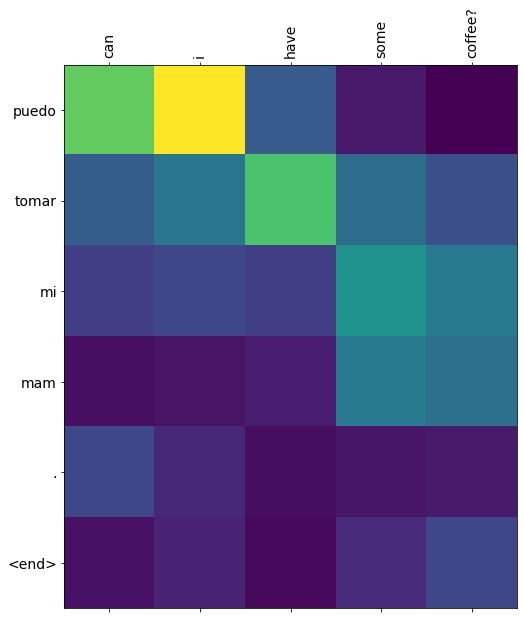

In [20]:
def evaluate(sentence, encoder, decoder):
    attention = np.zeros((dec_train.shape[-1], enc_train.shape[-1]))
    
    sentence = preprocess_sentence(sentence)
    inputs = enc_tokenizer.texts_to_sequences([sentence.split()])
    inputs = tf.keras.preprocessing.sequence.pad_sequences(inputs,
                                                           maxlen=enc_train.shape[-1],
                                                           padding='post')

    result = ''

    enc_out = encoder(inputs)

    dec_hidden = enc_out[:, -1]
    dec_input = tf.expand_dims([dec_tokenizer.word_index['<start>']], 0)

    for t in range(dec_train.shape[-1]):
        predictions, dec_hidden, attention_weights = decoder(dec_input,
                                                             dec_hidden,
                                                             enc_out)

        attention_weights = tf.reshape(attention_weights, (-1, ))
        attention[t] = attention_weights.numpy()

        predicted_id = \
        tf.argmax(tf.math.softmax(predictions, axis=-1)[0]).numpy()

        result += dec_tokenizer.index_word[predicted_id] + ' '

        if dec_tokenizer.index_word[predicted_id] == '<end>':
            return result, sentence, attention

        dec_input = tf.expand_dims([predicted_id], 0)

    return result, sentence, attention


def plot_attention(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
    ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


def translate(sentence, encoder, decoder):
    result, sentence, attention = evaluate(sentence, encoder, decoder)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))
    
    attention = attention[:len(result.split()), :len(sentence.split())]
    plot_attention(attention, sentence.split(), result.split(' '))


translate("Can I have some coffee?", encoder, decoder)

## 오늘 집에 들어가셔서 공부해야할 숙제
한-영 번역기 만들기
1. 데이터 다운로드
- 데이터 : https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1
- korean-english-park.train.tar.gz
2. 데이터 정제
- set 데이터형이 중복이 허용하지 않다는 것을 활용해 중복된 데이터를 제거
  - 데이터 병렬 쌍이 흐트러지지 않게 주의!
  - cleaned_corpus에 저장
- 앞서 정의한 preprocessing()함수는 한글에 대해 동작하지 않아요.
  - 한글에 적용할 수 있는 정규식을 추가해여 함수를 재정의 하세요.
- 타겟 언어인 영문엔 <start>토큰과 <end>토큰을 추가하고 split()함수로 토큰화 합니다. 한글 토큰화는 konlpy의 mecab클래스를 사용합니다.
  - cleaned_corpus로부터 토큰의길이가 40이하인 데이터를 선별하여 eng_corpus와 kor_corpus를 각각 구축하기

3. 토큰화
- tokenize()함수를 사용해 데이터를 텐서로 변환하고 각각의 tokenizer를 얻으세요!
  - 단어수는 실험을 통해 적당한 값을 맞춰줍시다(최소 10000이상!)
4. 훈련하기